In [20]:
import numpy as np
import pandas as pd

# Problem 1 (pre-processing)

In [21]:
#Read in the data
customers = pd.read_csv("mallcustomers.csv")

#Preview the dataset
customers.head()

,CustomerID,Gender,Age,Income,SpendingScore
0,1,Male,19,"15,000 USD",39
1,2,Male,21,"15,000 USD",81
2,3,Female,20,"16,000 USD",6
3,4,Female,23,"16,000 USD",77
4,5,Female,31,"17,000 USD",40


In [22]:
#Get data types
customers.dtypes

CustomerID        int64
Gender           object
Age               int64
Income           object
SpendingScore     int64
dtype: object

In [23]:
#Remove the substrings "," and "USD" from the Income column
customers["Income"] = customers["Income"].str.replace("USD", "", regex=False)
customers["Income"] = customers["Income"].str.replace(",", "", regex=False)

In [24]:
#Convert Income datatype to Numeric
customers["Income"] = pd.to_numeric(customers["Income"])

#Confirm Income is now Numeric
customers["Income"].dtypes

dtype('int64')

# Problem 2 (pre-processing)

In [25]:
#Drop CustomerID
customers = customers.drop(columns=["CustomerID"])

#Confirm CustomerID is dropped
customers.head()

,Gender,Age,Income,SpendingScore
0,Male,19,15000,39
1,Male,21,15000,81
2,Female,20,16000,6
3,Female,23,16000,77
4,Female,31,17000,40


# Problem 3 (pre-processing)

In [26]:
#Display summary statistics for Income and SpendingScore
customers[["Income", "SpendingScore"]].describe()

,Income,SpendingScore
count,200.000000,200.000000
mean,60560.000000,50.200000
std,26264.721165,25.823522
min,15000.000000,1.000000
25%,41500.000000,34.750000
50%,61500.000000,50.000000
75%,78000.000000,73.000000
max,137000.000000,99.000000


In [27]:
#Normalize the data
from sklearn.preprocessing import StandardScaler

X = customers[["Income", "SpendingScore"]]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# Problem 4 (Data Clustering)

In [28]:
import warnings
warnings.filterwarnings("ignore", category = UserWarning, module = "matplotlib")

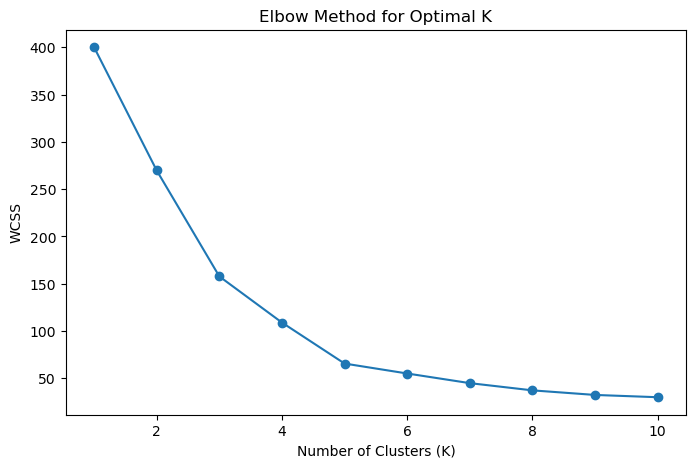

In [29]:
#Determine the optimal number of clusters (Elbow Method)
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters = k, random_state = 42, n_init = 10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

#Plot the Elbow Method
plt.figure(figsize = (8, 5))
plt.plot(K_range, wcss, marker = "o", linestyle = "-")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method for Optimal K")
plt.show()

According to the Elbow plot above, the optimal amount of clusters appears to be 5.

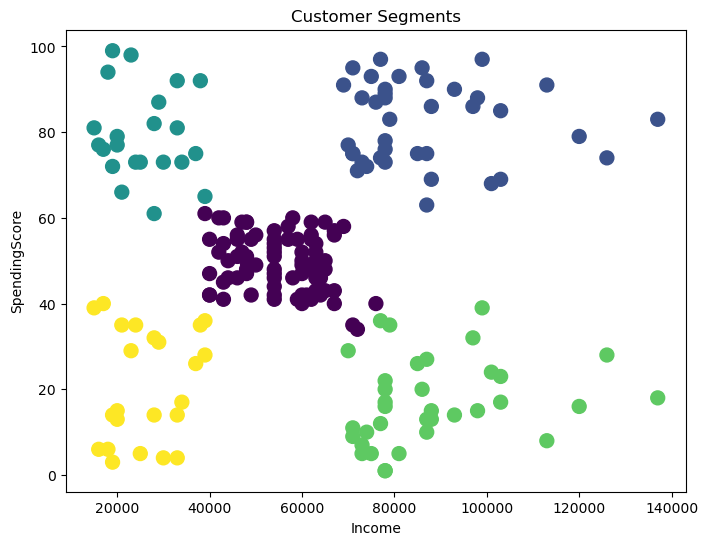

In [30]:
#Create the final set of clusters and visualize the results
kmeans_final = KMeans(n_clusters = 5, random_state = 42, n_init = 10)
kmeans_final.fit(X_scaled)
customers["Cluster"] = kmeans_final.labels_

plt.figure(figsize=(8,6))
plt.scatter(customers["Income"],
            customers["SpendingScore"],
            c=customers["Cluster"],
            s = 100)
plt.title("Customer Segments")
plt.xlabel("Income")
plt.ylabel("SpendingScore")
plt.show()

In [31]:
#See which cluster each customer falls into
customers.head(10)

,Gender,Age,Income,SpendingScore,Cluster
0,Male,19,15000,39,4
1,Male,21,15000,81,2
2,Female,20,16000,6,4
3,Female,23,16000,77,2
4,Female,31,17000,40,4
5,Female,22,17000,76,2
6,Female,35,18000,6,4
7,Female,23,18000,94,2
8,Male,64,19000,3,4
9,Female,30,19000,72,2


In [32]:
customers.tail(10)

,Gender,Age,Income,SpendingScore,Cluster
190,Female,34,103000,23,3
191,Female,32,103000,69,1
192,Male,33,113000,8,3
193,Female,38,113000,91,1
194,Female,47,120000,16,3
195,Female,35,120000,79,1
196,Female,45,126000,28,3
197,Male,32,126000,74,1
198,Male,32,137000,18,3
199,Male,30,137000,83,1


# Problem 5 (Evaluating the Clusters)

In [33]:
#Get additional cluster insight
customers.groupby("Cluster")[["Income", "SpendingScore"]].mean()

,Income,SpendingScore
Cluster,,
0,55296.296296,49.518519
1,86538.461538,82.128205
2,25727.272727,79.363636
3,88200.000000,17.114286
4,26304.347826,20.913043


In [34]:
#Assign names based on income and spending habits of each cluster

cluster_names = {
    0: "Average Shoppers",
    1: "Premium Shoppers",
    2: "Value Shoppers",
    3: "Potential Shoppers",
    4: "Low Engagement Shoppers"}

#Add cluster names column to the dataset for better visualization
customers["Segment"] = customers["Cluster"].map(cluster_names)

customers.head()

,Gender,Age,Income,SpendingScore,Cluster,Segment
0,Male,19,15000,39,4,Low Engagement Shoppers
1,Male,21,15000,81,2,Value Shoppers
2,Female,20,16000,6,4,Low Engagement Shoppers
3,Female,23,16000,77,2,Value Shoppers
4,Female,31,17000,40,4,Low Engagement Shoppers


In [35]:
customers.tail()

,Gender,Age,Income,SpendingScore,Cluster,Segment
195,Female,35,120000,79,1,Premium Shoppers
196,Female,45,126000,28,3,Potential Shoppers
197,Male,32,126000,74,1,Premium Shoppers
198,Male,32,137000,18,3,Potential Shoppers
199,Male,30,137000,83,1,Premium Shoppers


In [36]:
#Get customer segment counts for additional insight
customers["Segment"].value_counts()

Segment
Average Shoppers           81
Premium Shoppers           39
Potential Shoppers         35
Low Engagement Shoppers    23
Value Shoppers             22
Name: count, dtype: int64

In [37]:
#Create two dummy variable (Male and Female) to represent the Gender feature
gender_dummies = pd.get_dummies(customers["Gender"])

customers = pd.concat([customers, gender_dummies], axis = 1)

In [38]:
#Group customers by Segment and calculate demographic metrics
demographic_metrics = customers.groupby("Segment").agg(
    Mean_Age = ("Age", "mean"),
    Male_Count = ("Male", "sum"),
    Female_Count = ("Female", "sum"),
    Total_Customers = ("Segment", "count"))

demographic_metrics

,Mean_Age,Male_Count,Female_Count,Total_Customers
Segment,,,,
Average Shoppers,42.716049,33,48,81
Low Engagement Shoppers,45.217391,9,14,23
Potential Shoppers,41.114286,19,16,35
Premium Shoppers,32.692308,18,21,39
Value Shoppers,25.272727,9,13,22


The Premium Shoppers and Value Shoppers have the highest SpendingScores, and I noticed the average age of those two groups is the youngest among the 5. The Value Shoppers have lower income levels than the Premium Shoppers, which makes sense considering their average age (25) would represent someone relatively new to the workforce, while the average age of the Premium Shoppers (33) would represent a more seasoned worker.

The Potential Shoppers have similar income levels but far lower SpendingScores than the Premium Shoppers. The only telling difference between the two groups is age, as the Potential Shoppers are on average 8-9 years older than the Premium Shoppers. While age may play a factor, there are likely other factors not considered/included in the data set that we were originally provided with.

The Average Shopper is the largest group, representing 81 of the 200 customers we have data on. The Low Engagement Shoppers have similar income levels as the Value Shoppers, but on average they are 20 years older than the Value Shoppers. This tells me their low SpendingScores could be due to affordability issues.

I don't notice any stark differences in gender count in any of the customer segments. It appears the biggest factors attributing to SpendingScore is Income and Age.